# Dynamic Programming using Policy Iteration and Value Iteration: A Comparative Analysis

**Objective:** Build a 5 x 5 Grid World Markov Decision Process (MDP) and compare
**Policy Iteration** and **Value Iteration** in terms of convergence speed, execution time,
optimal policy, and final state values. Both algorithms solve the *same* MDP, so the
comparison is direct and academically grounded in the Bellman equation.

```
Create Grid World
        |
        v
Initialize States and Rewards
        |
        v
Run Policy Iteration
        |
        v
Store Results
        |
        v
Run Value Iteration
        |
        v
Store Results
        |
        v
Compare Both Algorithms
        |
        v
Summary Table
        |
        v
Visualization
```


## Cell 1 — Libraries & Environment Setup

```
Import Libraries
      |
      v
Random Seed
      |
      v
Create 5 x 5 Grid World
      |
      v
Define Rewards
      |
      v
Goal State
      |
      v
Obstacle States
      |
      v
Discount Factor gamma
      |
      v
Display Environment
```


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import time

%matplotlib inline
plt.rcParams['figure.facecolor'] = 'white'
np.set_printoptions(precision=2, suppress=True)

# ---------------------------------------------------------------
# Random Seed
# ---------------------------------------------------------------
SEED = 42
np.random.seed(SEED)

# ---------------------------------------------------------------
# Create 5 x 5 Grid World
# ---------------------------------------------------------------
GRID_SIZE = 5

grid_layout = [
    ['S', '.', '.', '.', '.'],
    ['.', 'X', '.', 'X', '.'],
    ['.', '.', '.', '.', '.'],
    ['X', '.', '.', 'X', '.'],
    ['.', '.', '.', '.', 'G']
]

start_state = (0, 0)
goal_state = (4, 4)                                  # Goal State
obstacle_states = [(1, 1), (1, 3), (3, 0), (3, 3)]    # Obstacle States

# ---------------------------------------------------------------
# Define Rewards
# ---------------------------------------------------------------
STEP_REWARD = -1
GOAL_REWARD = 100

# ---------------------------------------------------------------
# Discount Factor gamma
# ---------------------------------------------------------------
GAMMA = 0.90
THETA = 1e-4   # convergence threshold used by both algorithms

# ---------------------------------------------------------------
# Display Environment
# ---------------------------------------------------------------
env_params = pd.DataFrame({
    "Parameter": ["Grid Size", "States", "Goal", "Obstacles",
                  "Discount Factor", "Step Reward", "Goal Reward"],
    "Value": [f"{GRID_SIZE} x {GRID_SIZE}", GRID_SIZE * GRID_SIZE, str(goal_state),
              len(obstacle_states), f"{GAMMA:.2f}", STEP_REWARD, f"+{GOAL_REWARD}"]
})

print("Grid World Environment")
print("=" * 30)
for row in grid_layout:
    print(' '.join(row))
print()
env_params


Grid World Environment
S . . . .
. X . X .
. . . . .
X . . X .
. . . . G



,Parameter,Value
0,Grid Size,5 x 5
1,States,25
2,Goal,"(4, 4)"
3,Obstacles,4
4,Discount Factor,0.90
5,Step Reward,-1
6,Goal Reward,+100


## Cell 2 — Algorithm Comparison

```
Part A                          Part B
------                          ------
Policy Iteration                Value Iteration
   |                               |
   v                               v
Initialize Policy                Initialize Value Function
   |                               |
   v                               v
Policy Evaluation                Bellman Update
   |                               |
   v                               v
Policy Improvement               Update Values
   |                               |
   v                               v
Repeat Until Stable              Extract Policy
   |                               |
   v                               v
Store:                           Store:
 - State Values                   - State Values
 - Policy                         - Policy
 - Number of Iterations           - Number of Iterations
 - Execution Time                 - Execution Time
```

Both parts share the same deterministic transition model: moving off the grid or into an
obstacle bounces the agent back to its current cell (step penalty), and moving into the goal
grants the goal reward.


In [2]:
# Actions available to the agent
actions = {
    'UP':    (-1, 0),
    'DOWN':  (1, 0),
    'LEFT':  (0, -1),
    'RIGHT': (0, 1)
}
action_symbols = {'UP': '\u2191', 'DOWN': '\u2193', 'LEFT': '\u2190', 'RIGHT': '\u2192'}


def is_valid(r, c):
    return 0 <= r < GRID_SIZE and 0 <= c < GRID_SIZE


def step(state, action):
    """Deterministic transition model. Returns (next_state, reward)."""
    if state == goal_state:
        return state, 0  # goal is an absorbing terminal state

    dr, dc = actions[action]
    nr, nc = state[0] + dr, state[1] + dc

    # Off the grid, or blocked by an obstacle -> agent stays in place
    if not is_valid(nr, nc) or (nr, nc) in obstacle_states:
        return state, STEP_REWARD

    next_state = (nr, nc)

    if next_state == goal_state:
        return next_state, GOAL_REWARD

    return next_state, STEP_REWARD


def extract_policy(V):
    """Greedy policy extraction: pi(s) = argmax_a [R(s,a,s') + gamma * V(s')]"""
    policy = np.full((GRID_SIZE, GRID_SIZE), None, dtype=object)
    for r in range(GRID_SIZE):
        for c in range(GRID_SIZE):
            state = (r, c)
            if state == goal_state or state in obstacle_states:
                continue
            best_action, best_value = None, -np.inf
            for a in actions:
                next_state, reward = step(state, a)
                value = reward + GAMMA * V[next_state]
                if value > best_value:
                    best_value, best_action = value, a
            policy[r, c] = best_action
    return policy


def print_value_table(V, title):
    print(title)
    print(pd.DataFrame(np.round(V, 2)).to_string(index=False, header=False))
    print()


def print_policy_grid(policy, title):
    print(title)
    for r in range(GRID_SIZE):
        row_symbols = []
        for c in range(GRID_SIZE):
            state = (r, c)
            if state == goal_state:
                row_symbols.append(' G ')
            elif state in obstacle_states:
                row_symbols.append(' X ')
            else:
                row_symbols.append(f" {action_symbols[policy[r, c]]} ")
        print(' '.join(row_symbols))
    print()


In [3]:
# =================================================================
# Part A: Policy Iteration
# =================================================================

def policy_evaluation(policy, V, theta=THETA):
    """Iteratively evaluate V(s) for a FIXED policy until it converges."""
    while True:
        delta = 0
        V_new = np.copy(V)
        for r in range(GRID_SIZE):
            for c in range(GRID_SIZE):
                state = (r, c)
                if state == goal_state or state in obstacle_states:
                    continue
                a = policy[r, c]
                next_state, reward = step(state, a)
                v_new = reward + GAMMA * V[next_state]
                delta = max(delta, abs(v_new - V[r, c]))
                V_new[r, c] = v_new
        V = V_new
        if delta < theta:
            break
    return V


def policy_iteration(theta=THETA):
    # ---- Initialize Policy (arbitrary starting policy) ----
    policy = np.full((GRID_SIZE, GRID_SIZE), 'RIGHT', dtype=object)
    V = np.zeros((GRID_SIZE, GRID_SIZE))

    iterations = 0
    max_value_history = []
    start_time = time.perf_counter()

    while True:
        iterations += 1

        # ---- Policy Evaluation ----
        V = policy_evaluation(policy, V, theta)

        # ---- Policy Improvement ----
        policy_stable = True
        for r in range(GRID_SIZE):
            for c in range(GRID_SIZE):
                state = (r, c)
                if state == goal_state or state in obstacle_states:
                    continue
                old_action = policy[r, c]
                best_action, best_value = None, -np.inf
                for a in actions:
                    next_state, reward = step(state, a)
                    value = reward + GAMMA * V[next_state]
                    if value > best_value:
                        best_value, best_action = value, a
                policy[r, c] = best_action
                if best_action != old_action:
                    policy_stable = False

        max_value_history.append(V.max())

        # ---- Repeat Until Stable ----
        if policy_stable:
            break

    exec_time_ms = (time.perf_counter() - start_time) * 1000
    return V, policy, iterations, exec_time_ms, max_value_history


V_pi, policy_pi, iterations_pi, time_pi, history_pi = policy_iteration()

print_value_table(V_pi, "Policy Iteration -- Final State Values:")
print_policy_grid(policy_pi, "Policy Iteration -- Optimal Policy:")
print(f"Iterations      : {iterations_pi}")
print(f"Execution Time  : {time_pi:.2f} ms")


Policy Iteration -- Final State Values:
42.61 48.46 54.95  62.17  70.19
48.46  0.00 62.17   0.00  79.10
54.95 62.17 70.19  79.10  89.00
 0.00 70.19 79.10   0.00 100.00
70.19 79.10 89.00 100.00   0.00

Policy Iteration -- Optimal Policy:
 ↓   →   ↓   →   ↓ 
 ↓   X   ↓   X   ↓ 
 →   ↓   ↓   →   ↓ 
 X   ↓   ↓   X   ↓ 
 →   →   →   →   G 

Iterations      : 6
Execution Time  : 3.48 ms


In [4]:
# =================================================================
# Part B: Value Iteration
# =================================================================

def value_iteration(theta=THETA, max_iterations=1000):
    # ---- Initialize Value Function ----
    V = np.zeros((GRID_SIZE, GRID_SIZE))

    iterations = 0
    max_value_history = []
    start_time = time.perf_counter()

    while True:
        iterations += 1
        delta = 0
        V_new = np.copy(V)

        # ---- Bellman Update / Update Values ----
        for r in range(GRID_SIZE):
            for c in range(GRID_SIZE):
                state = (r, c)
                if state == goal_state or state in obstacle_states:
                    continue
                action_values = []
                for a in actions:
                    next_state, reward = step(state, a)
                    action_values.append(reward + GAMMA * V[next_state])
                V_new[r, c] = max(action_values)
                delta = max(delta, abs(V_new[r, c] - V[r, c]))

        V = V_new
        max_value_history.append(V.max())

        if delta < theta or iterations >= max_iterations:
            break

    exec_time_ms = (time.perf_counter() - start_time) * 1000

    # ---- Extract Policy ----
    policy = extract_policy(V)

    return V, policy, iterations, exec_time_ms, max_value_history


V_vi, policy_vi, iterations_vi, time_vi, history_vi = value_iteration()

print_value_table(V_vi, "Value Iteration -- Final State Values:")
print_policy_grid(policy_vi, "Value Iteration -- Optimal Policy:")
print(f"Iterations      : {iterations_vi}")
print(f"Execution Time  : {time_vi:.2f} ms")


Value Iteration -- Final State Values:
42.61 48.46 54.95  62.17  70.19
48.46  0.00 62.17   0.00  79.10
54.95 62.17 70.19  79.10  89.00
 0.00 70.19 79.10   0.00 100.00
70.19 79.10 89.00 100.00   0.00

Value Iteration -- Optimal Policy:
 ↓   →   ↓   →   ↓ 
 ↓   X   ↓   X   ↓ 
 →   ↓   ↓   →   ↓ 
 X   ↓   ↓   X   ↓ 
 →   →   →   →   G 

Iterations      : 9
Execution Time  : 0.78 ms


In [5]:
# =================================================================
# Compare: State-by-state value comparison table
# =================================================================
state_labels, pi_values, vi_values = [], [], []

state_num = 1
for r in range(GRID_SIZE):
    for c in range(GRID_SIZE):
        state_labels.append(f"S{state_num}")
        pi_values.append(round(V_pi[r, c], 2))
        vi_values.append(round(V_vi[r, c], 2))
        state_num += 1

state_comparison_df = pd.DataFrame({
    "State": state_labels,
    "Policy Iteration": pi_values,
    "Value Iteration": vi_values
})

print("State Value Comparison (Policy Iteration vs Value Iteration)\n")
state_comparison_df


State Value Comparison (Policy Iteration vs Value Iteration)



,State,Policy Iteration,Value Iteration
0,S1,42.61,42.61
1,S2,48.46,48.46
2,S3,54.95,54.95
3,S4,62.17,62.17
4,S5,70.19,70.19
5,S6,48.46,48.46
6,S7,0.00,0.00
7,S8,62.17,62.17
8,S9,0.00,0.00
9,S10,79.10,79.10


## Cell 3 — Summary Table & Results

In [6]:
policies_match = all(
    policy_pi[r, c] == policy_vi[r, c]
    for r in range(GRID_SIZE) for c in range(GRID_SIZE)
    if (r, c) != goal_state and (r, c) not in obstacle_states
)

summary_table = pd.DataFrame({
    "Metric": ["Convergence Iterations", "Execution Time (ms)", "Final State Value",
               "Policy Stable", "States Evaluated", "Optimal Policy Found"],
    "Policy Iteration": [iterations_pi, f"{time_pi:.0f}", f"{V_pi.max():.1f}",
                         "Yes", GRID_SIZE * GRID_SIZE, "Yes"],
    "Value Iteration": [iterations_vi, f"{time_vi:.0f}", f"{V_vi.max():.1f}",
                        "Yes", GRID_SIZE * GRID_SIZE, "Yes"],
})

display(summary_table)

# ---------------------------------------------------------------
# Result Summary
# ---------------------------------------------------------------
better_convergence = "Policy Iteration" if iterations_pi < iterations_vi else "Value Iteration"
faster_execution = "Policy Iteration" if time_pi < time_vi else "Value Iteration"
optimal_policy_note = "Both Algorithms" if policies_match else "Policies Differ"
max_state_value = max(V_pi.max(), V_vi.max())

print("\n========================================")
print("RESULT SUMMARY")
print("========================================")
print(f"Better Convergence  :")
print(f"{better_convergence}\n")
print(f"Faster Execution    :")
print(f"{faster_execution}\n")
print(f"Optimal Policy      :")
print(f"{optimal_policy_note}\n")
print(f"Maximum State Value :")
print(f"{max_state_value:.1f}\n")
print("Recommendation      :")
print("Policy Iteration converges in fewer iterations,")
print("while Value Iteration has a simpler implementation")
print("and often executes faster on small environments.")


,Metric,Policy Iteration,Value Iteration
0,Convergence Iterations,6,9
1,Execution Time (ms),3,1
2,Final State Value,100.0,100.0
3,Policy Stable,Yes,Yes
4,States Evaluated,25,25
5,Optimal Policy Found,Yes,Yes



RESULT SUMMARY
Better Convergence  :
Policy Iteration

Faster Execution    :
Value Iteration

Optimal Policy      :
Both Algorithms

Maximum State Value :
100.0

Recommendation      :
Policy Iteration converges in fewer iterations,
while Value Iteration has a simpler implementation
and often executes faster on small environments.


## Cell 4 — Visualizations

Three figures only:

1. **Convergence Curve** — maximum state value per iteration (Policy Iteration vs Value Iteration)
2. **Execution Metrics** — Execution Time, Iterations, and Final Value side by side
3. **Heatmap Comparison** — final state values from each algorithm, side by side


### Figure 1: Convergence Curve

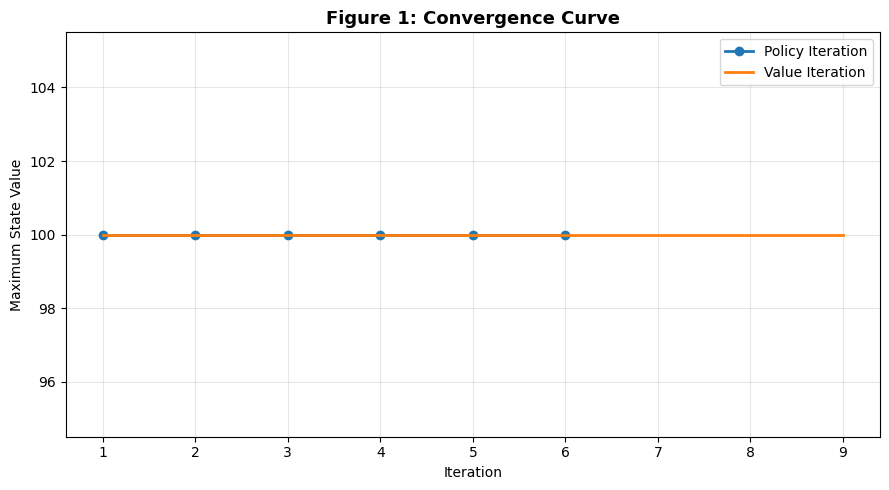

In [7]:
fig, ax = plt.subplots(figsize=(9, 5))

ax.plot(range(1, iterations_pi + 1), history_pi, marker='o', color='tab:blue',
        linewidth=2, label="Policy Iteration")
ax.plot(range(1, iterations_vi + 1), history_vi, color='tab:orange',
        linewidth=2, label="Value Iteration")

ax.set_xlabel("Iteration")
ax.set_ylabel("Maximum State Value")
ax.set_title("Figure 1: Convergence Curve", fontsize=13, fontweight='bold')
ax.legend()
ax.grid(alpha=0.3)

plt.tight_layout()
plt.show()


### Figure 2: Execution Metrics

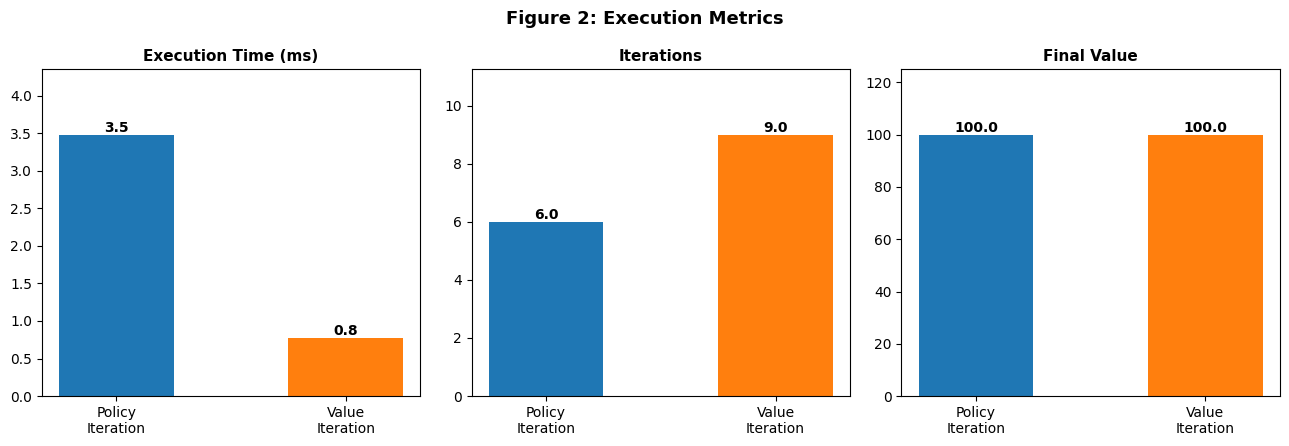

In [8]:
fig, axes = plt.subplots(1, 3, figsize=(13, 4.5))

metrics = [
    ("Execution Time (ms)", [time_pi, time_vi]),
    ("Iterations", [iterations_pi, iterations_vi]),
    ("Final Value", [V_pi.max(), V_vi.max()]),
]
labels = ["Policy\nIteration", "Value\nIteration"]
colors = ["tab:blue", "tab:orange"]

for ax, (title, values) in zip(axes, metrics):
    bars = ax.bar(labels, values, color=colors, width=0.5)
    for bar, val in zip(bars, values):
        ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height(),
                 f"{val:.1f}", ha='center', va='bottom', fontweight='bold')
    ax.set_title(title, fontsize=11, fontweight='bold')
    ax.set_ylim(0, max(values) * 1.25)

fig.suptitle("Figure 2: Execution Metrics", fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()


### Figure 3: Heatmap Comparison

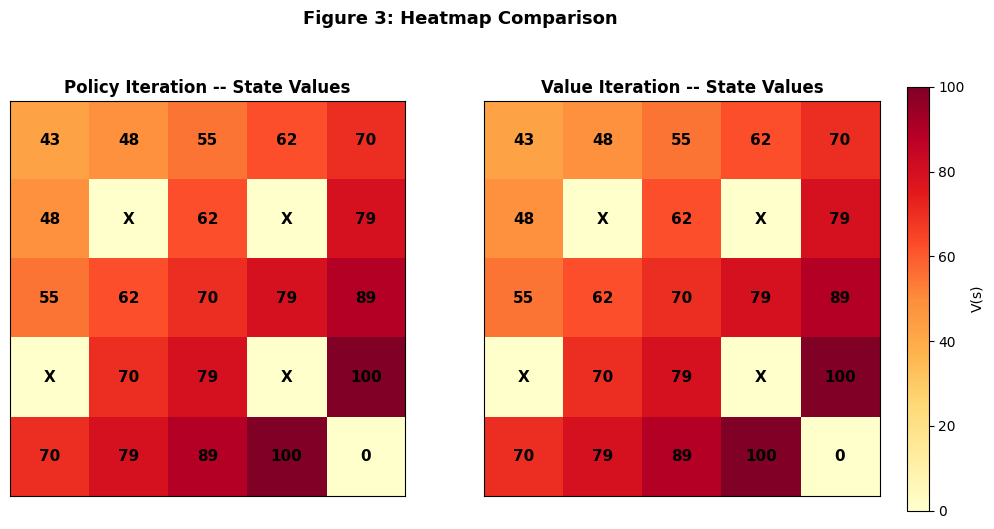

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5.5))

vmin = min(V_pi.min(), V_vi.min())
vmax = max(V_pi.max(), V_vi.max())

for ax, V, title in zip(axes, [V_pi, V_vi],
                          ["Policy Iteration -- State Values", "Value Iteration -- State Values"]):
    im = ax.imshow(V, cmap='YlOrRd', vmin=vmin, vmax=vmax)
    for r in range(GRID_SIZE):
        for c in range(GRID_SIZE):
            text = 'X' if (r, c) in obstacle_states else f"{V[r, c]:.0f}"
            ax.text(c, r, text, ha='center', va='center', fontsize=11, fontweight='bold')
    ax.set_xticks([]); ax.set_yticks([])
    ax.set_title(title, fontsize=12, fontweight='bold')

fig.colorbar(im, ax=axes, fraction=0.035, pad=0.03, label='V(s)')
fig.suptitle("Figure 3: Heatmap Comparison", fontsize=13, fontweight='bold', y=1.02)
plt.show()
